# Sanity Check - Model, Loss and Dataloader

In [ ]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

from datasets.custom_cnn_dataset import get_dataloader
from models.custom_cnn import CustomCNN, CustomCNNLoss

## 1. Shape and Loss Sanity Check

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

loader = get_dataloader("train", batch_size=4, num_workers=0)
images, labels = next(iter(loader))

model     = CustomCNN().to(device)
criterion = CustomCNNLoss()

with torch.no_grad():
    preds = model(images.to(device))

loss = criterion(preds, labels.to(device))

print(f"images : {tuple(images.shape)}   expected: (4, 3, 448, 448)")
print(f"labels : {tuple(labels.shape)}   expected: (4, N, 5)")
print(f"preds  : {tuple(preds.shape)}   expected: (4, 7, 7, 13)")
print(f"loss   : {loss.item():.4f}")
print("✓ Sanity check passed.")

Device: cuda
images : (4, 3, 448, 448)   expected: (4, 3, 448, 448)
labels : (4, 9, 5)   expected: (4, N, 5)
preds  : (4, 7, 7, 13)   expected: (4, 7, 7, 13)
loss   : 18.6287
✓ Sanity check passed.


## 2. Bbox Visualization

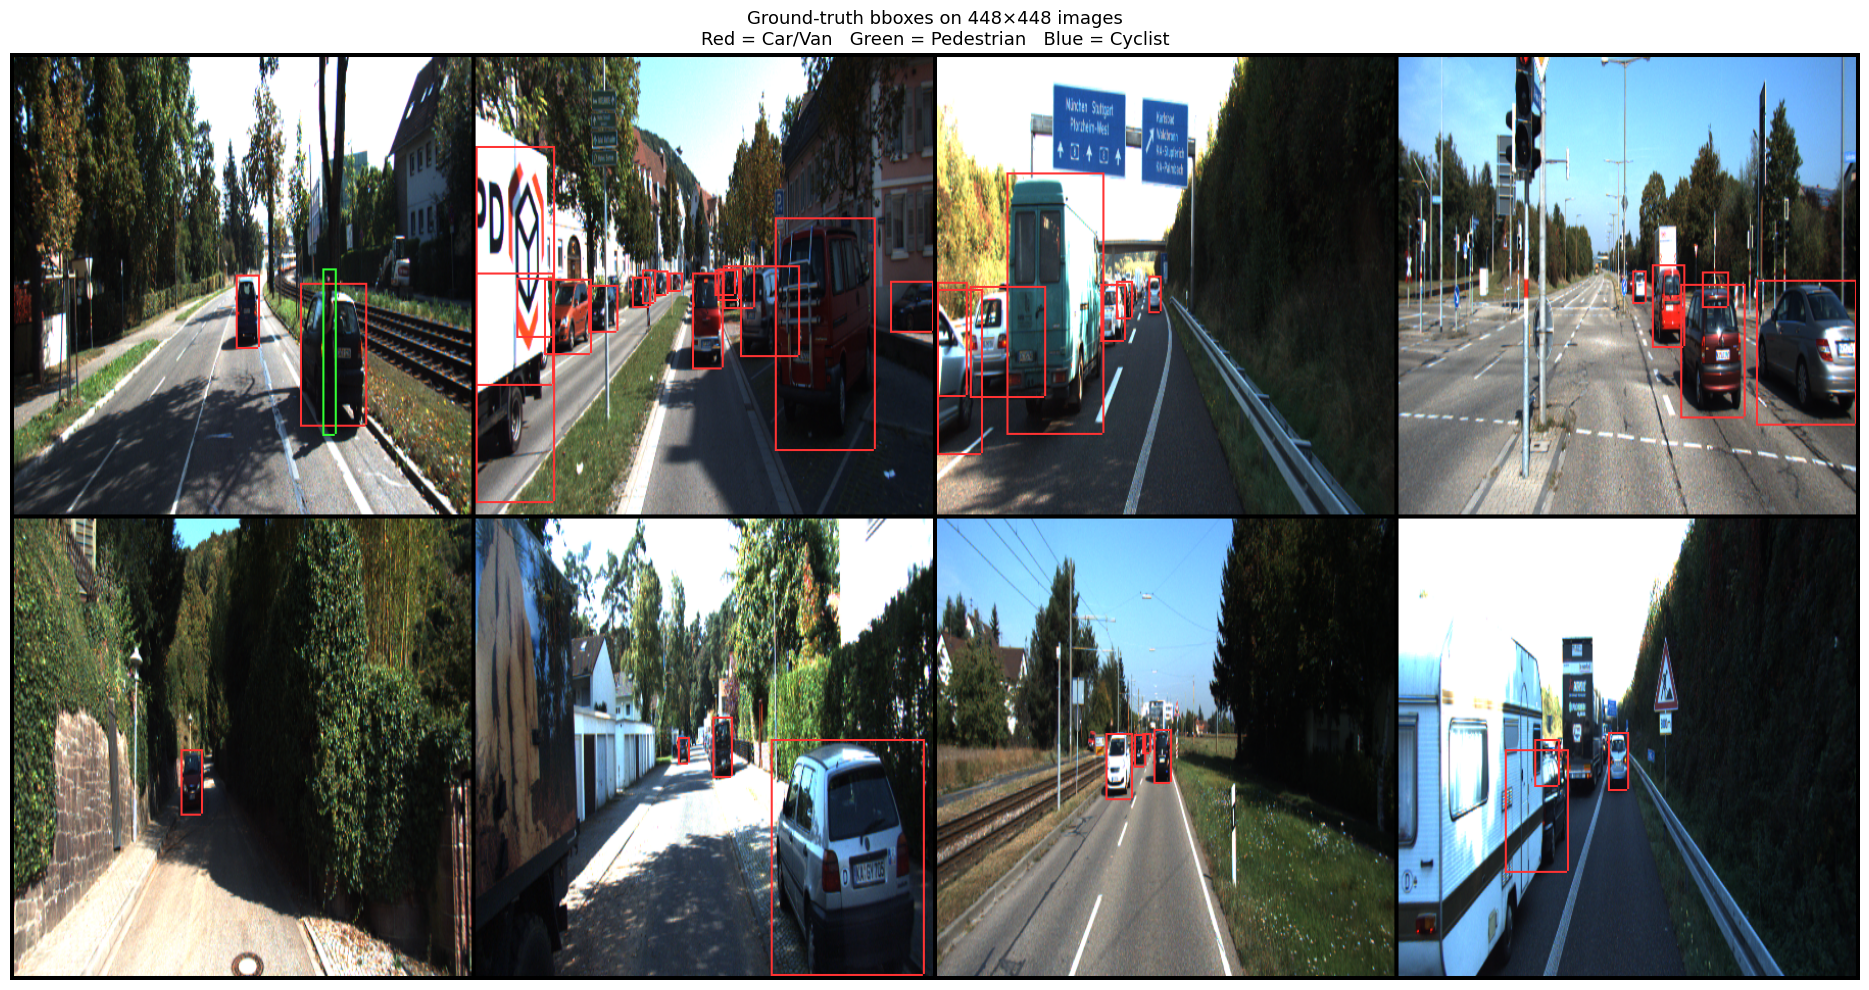

  Car/Van: 41 boxes in this batch
  Pedestrian: 1 boxes in this batch
  Cyclist: 0 boxes in this batch


In [ ]:
CLASS_COLORS = {0: (1.0, 0.2, 0.2), 1: (0.2, 1.0, 0.2), 2: (0.2, 0.6, 1.0)}
CLASS_NAMES  = {0: "Car/Van", 1: "Pedestrian", 2: "Cyclist"}


def draw_boxes(image, boxes):
    img = image.clone()
    H, W = img.shape[1], img.shape[2]
    for box in boxes:
        cls_id = int(box[0].item())
        if cls_id < 0:
            continue
        cx, cy, w, h = box[1].item(), box[2].item(), box[3].item(), box[4].item()
        x1 = max(0, int((cx - w / 2) * W))
        y1 = max(0, int((cy - h / 2) * H))
        x2 = min(W - 1, int((cx + w / 2) * W))
        y2 = min(H - 1, int((cy + h / 2) * H))
        color = CLASS_COLORS.get(cls_id, (1.0, 1.0, 0.0))
        for c, v in enumerate(color):
            img[c, y1:y1+2, x1:x2] = v
            img[c, y2:y2+2, x1:x2] = v
            img[c, y1:y2, x1:x1+2] = v
            img[c, y1:y2, x2:x2+2] = v
    return img


vis_loader = get_dataloader("train", batch_size=8, num_workers=0, shuffle=True)
images, labels = next(iter(vis_loader))

annotated = torch.stack([draw_boxes(images[i], labels[i]) for i in range(8)])
grid = vutils.make_grid(annotated, nrow=4, padding=4)
grid_np = grid.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(20, 10))
ax.imshow(grid_np)
ax.axis("off")
ax.set_title("Ground-truth bboxes on 448×448 images\n"
             "Red = Car/Van   Green = Pedestrian   Blue = Cyclist", fontsize=13)
plt.tight_layout()
plt.show()

for cls_id, name in CLASS_NAMES.items():
    count = int((labels[..., 0] == cls_id).sum().item())
    print(f"  {name}: {count} boxes in this batch")